In [12]:
from grngen import *
import pandas as pd

In [ ]:
specie_list = [
    # 'GSD', 'HSC', 'mCAD', 'VSC', 
    'yeast','hESC', 'mESC', 
    'ecoli_gnw', 
    'human_trrust', 
    # "athaliana_wolf", "dmelanogaster_wolf",  "hsapiens_wolf", "scerevisiae_wolf",
    "ecoli_wolf",
    'mDC'
    ]

for specie in specie_list:
    input_dir = f"../../data/graphs/" # reference graph and associated data folder path
    ground_truth_graph, _, _ = load_graphs(input_dir+specie)
    node_degree_sequence = get_node_degrees(ground_truth_graph)

    ngraphs = 1000 # number of iteration used only in the graph genration
    n_jobs = os.cpu_count() - 1

    output_dir = f"../../data/random_config_relax/c_cm_corrected/{specie}" # output folder path for graphs and aggregated data and plots
    
    if not os.path.exists(output_dir): # should be moved toward each plotting function to prevent issues
        os.makedirs(output_dir)

    _, _ = generate_random_graphs(
            ngraphs,
            ground_truth_in_degree,
            ground_truth_out_degree,
            None,
            None,
            ground_truth_graph,
            output_dir,
            specie,
            parallel=True,
            n_jobs=n_jobs,
            connect_type='random',
            method='c_cm',
            N=None
        )

In [ ]:
specie_list = [
    # 'GSD', 'HSC', 'mCAD', 'VSC', 
    'yeast','hESC', 'mESC', 
    'ecoli_gnw', 
    'human_trrust', 
    # "athaliana_wolf", "dmelanogaster_wolf",  "hsapiens_wolf", "scerevisiae_wolf",
    "ecoli_wolf",
    'mDC'
    ]

for specie in specie_list:
    input_dir = f"../../data/graphs/" # reference graph and associated data folder path
    ground_truth_graph, _, _ = load_graphs(input_dir+specie)
    node_degree_sequence = get_node_degrees(ground_truth_graph)
    graph_size = ground_truth_graph.number_of_nodes()
    timing_results = []
    for i in range(10):
        print(f"Running iteration {i+1}/10...")
        try:
            t_gen, t_comp = generate_one_graph_profiled(
                node_degree_sequence=node_degree_sequence, # Ensure this is defined
                specie=specie,                             # Ensure this is defined
                method="grngen"
            )
            timing_results.append({
                "graph_generation_time": t_gen,
                "property_computation_time": t_comp
            })
        except Exception as e:
            print(f"Failed at iteration {i}: {e}")

    # Save to CSV
    df_timing = pd.DataFrame(timing_results)
    df_timing['specie'] = specie
    df_timing['sizes'] = graph_size
    df_timing.to_csv(f"{specie}_execution_times.csv", index=False)

    print("Profiling complete. Results saved to 'execution_times.csv'.")

Loaded graph from ../../data/graphs/yeast_g.graphml.
Loaded graph stats from ../../data/graphs/yeast_stat.json.
Loaded graph motif counts from ../../data/graphs/yeast_motifs.json.
Running iteration 1/10...
Running iteration 2/10...
Running iteration 3/10...
Running iteration 4/10...
Running iteration 5/10...
Running iteration 6/10...
Running iteration 7/10...
Running iteration 8/10...
Running iteration 9/10...
Running iteration 10/10...
Profiling complete. Results saved to 'execution_times.csv'.
Loaded graph from ../../data/graphs/hESC_g.graphml.
Loaded graph stats from ../../data/graphs/hESC_stat.json.
Loaded graph motif counts from ../../data/graphs/hESC_motifs.json.
Running iteration 1/10...
Running iteration 2/10...
Running iteration 3/10...
Running iteration 4/10...
Running iteration 5/10...
Running iteration 6/10...
Running iteration 7/10...
Running iteration 8/10...
Running iteration 9/10...
Running iteration 10/10...
Profiling complete. Results saved to 'execution_times.csv'.
L

# Data processing

Aggregated Data Preview:
         specie  sizes  graph_gen_mean  graph_gen_std  graph_gen_sem  \
0     ecoli_gnw   1477        0.056549       0.011770       0.003722   
1    ecoli_wolf   1532        0.065703       0.020222       0.006395   
2          hESC   6532        1.085483       0.368267       0.116456   
3  human_trrust   2012        0.221465       0.050812       0.016068   
4           mDC   9371       20.246566       5.807406       1.836463   
5          mESC   6124        0.967379       0.323464       0.102288   
6         yeast   1703        0.043348       0.007298       0.002308   

   prop_comp_mean  prop_comp_std  prop_comp_sem  n_replicates  
0        2.523520       0.037968       0.012007            10  
1        2.651196       0.032316       0.010219            10  
2       68.698255       1.420375       0.449162            10  
3        4.758543       0.064021       0.020245            10  
4     1059.736826      19.726924       6.238201            10  
5       60.770

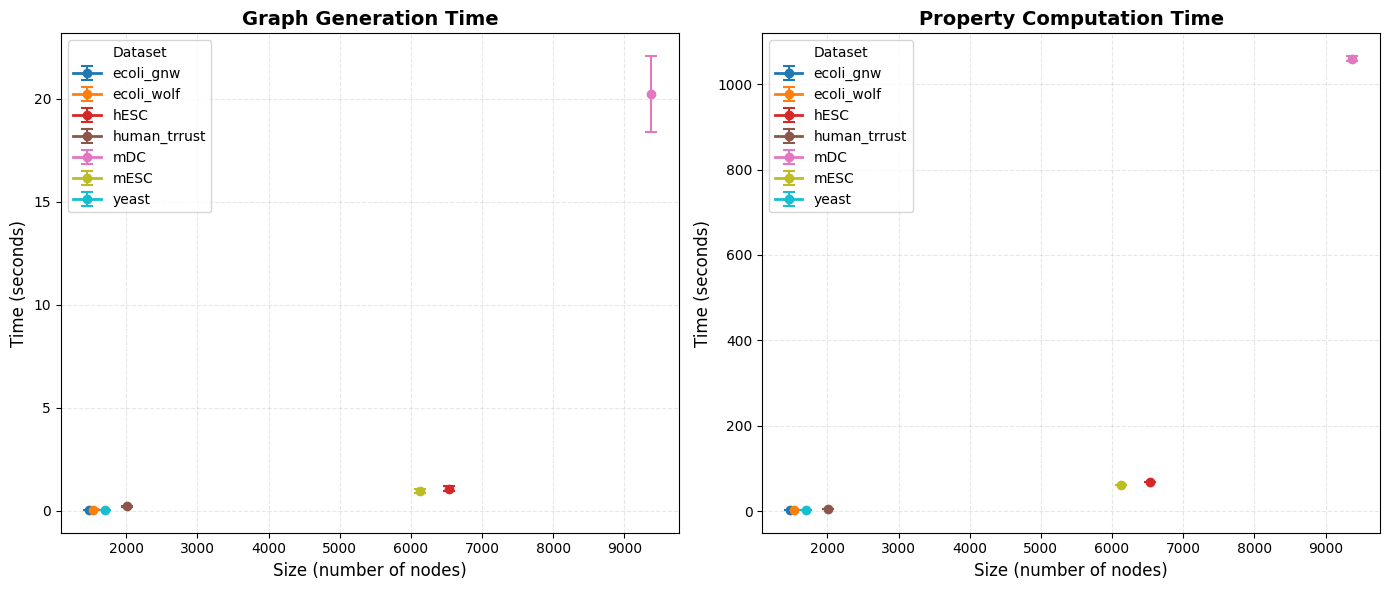

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path


def load_and_aggregate_data(data_directory: str, file_pattern: str = "*_execution_times.csv") -> pd.DataFrame:
    """
    Load all execution time CSV files and aggregate them into a single DataFrame.
    
    Parameters:
    -----------
    data_directory : str
        Path to the directory containing the CSV files
    file_pattern : str
        Glob pattern to match the files (default: "*_execution_times.csv")
    
    Returns:
    --------
    pd.DataFrame
        Aggregated DataFrame with columns: specie, sizes, graph_generation_time, 
        property_computation_time, and computed statistics
    """
    # Find all matching files
    file_paths = glob.glob(str(Path(data_directory) / file_pattern))
    
    if not file_paths:
        raise FileNotFoundError(f"No files matching '{file_pattern}' found in '{data_directory}'")
    
    # Load and concatenate all files
    all_data = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        # Extract specie name from filename if not in the data
        if 'specie' not in df.columns:
            specie_name = Path(file_path).stem.replace('_execution_times', '')
            df['specie'] = specie_name
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Compute aggregated statistics (mean, std, sem) grouped by specie and size
    aggregated = combined_df.groupby(['specie', 'sizes']).agg(
        graph_gen_mean=('graph_generation_time', 'mean'),
        graph_gen_std=('graph_generation_time', 'std'),
        graph_gen_sem=('graph_generation_time', 'sem'),
        prop_comp_mean=('property_computation_time', 'mean'),
        prop_comp_std=('property_computation_time', 'std'),
        prop_comp_sem=('property_computation_time', 'sem'),
        n_replicates=('graph_generation_time', 'count')
    ).reset_index()
    
    return aggregated


def plot_execution_times(
    aggregated_data: pd.DataFrame,
    time_column: str = 'both',
    error_type: str = 'sem',
    figsize: tuple = (12, 6),
    log_scale: bool = False,
    save_path: str = None
) -> plt.Figure:
    """
    Plot mean execution times with error bars for each size, grouped by specie.
    
    Parameters:
    -----------
    aggregated_data : pd.DataFrame
        Aggregated DataFrame from load_and_aggregate_data()
    time_column : str
        Which time to plot: 'graph_generation', 'property_computation', or 'both'
    error_type : str
        Type of error bars: 'std' for standard deviation, 'sem' for standard error
    figsize : tuple
        Figure size (width, height)
    log_scale : bool
        Whether to use logarithmic scale for y-axis
    save_path : str
        Path to save the figure (optional)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The generated figure
    """
    species = aggregated_data['specie'].unique()
    n_species = len(species)
    
    # Color palette
    colors = plt.cm.tab10(np.linspace(0, 1, n_species))
    
    # Determine subplot configuration
    if time_column == 'both':
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        plot_configs = [
            ('graph_gen', 'Graph Generation Time', axes[0]),
            ('prop_comp', 'Property Computation Time', axes[1])
        ]
    else:
        fig, ax = plt.subplots(1, 1, figsize=(figsize[0] // 2, figsize[1]))
        prefix = 'graph_gen' if time_column == 'graph_generation' else 'prop_comp'
        title = 'Graph Generation Time' if time_column == 'graph_generation' else 'Property Computation Time'
        plot_configs = [(prefix, title, ax)]
    
    for prefix, title, ax in plot_configs:
        for idx, specie in enumerate(species):
            specie_data = aggregated_data[aggregated_data['specie'] == specie].sort_values('sizes')
            
            sizes = specie_data['sizes'].values
            means = specie_data[f'{prefix}_mean'].values
            errors = specie_data[f'{prefix}_{error_type}'].values
            
            ax.errorbar(
                sizes, 
                means, 
                yerr=errors,
                label=specie,
                color=colors[idx],
                marker='o',
                markersize=6,
                capsize=4,
                capthick=1.5,
                linewidth=2,
                elinewidth=1.5
            )
        
        ax.set_xlabel('Size (number of nodes)', fontsize=12)
        ax.set_ylabel('Time (seconds)', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(title='Dataset', loc='upper left')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        if log_scale:
            ax.set_yscale('log')
            ax.set_xscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig


# 1. Load and aggregate data
data_dir = "."  # Change this to your data directory
aggregated_df = load_and_aggregate_data(data_dir)

print("Aggregated Data Preview:")
print(aggregated_df.head(10))
print(f"\nSpecies found: {aggregated_df['specie'].unique()}")
print(f"Sizes found: {sorted(aggregated_df['sizes'].unique())}")

# 2. Plot both metrics
fig = plot_execution_times(
    aggregated_df,
    time_column='both',
    error_type='sem',  # Use 'std' for standard deviation
    figsize=(14, 6),
    log_scale=False,
    save_path='execution_times_plot.png'
)

plt.show()

In [9]:
aggregated_df

,specie,sizes,graph_gen_mean,graph_gen_std,graph_gen_sem,prop_comp_mean,prop_comp_std,prop_comp_sem,n_replicates
0,ecoli_gnw,1477,0.056549,0.011770,0.003722,2.523520,0.037968,0.012007,10
1,ecoli_wolf,1532,0.065703,0.020222,0.006395,2.651196,0.032316,0.010219,10
2,hESC,6532,1.085483,0.368267,0.116456,68.698255,1.420375,0.449162,10
3,human_trrust,2012,0.221465,0.050812,0.016068,4.758543,0.064021,0.020245,10
4,mDC,9371,20.246566,5.807406,1.836463,1059.736826,19.726924,6.238201,10
5,mESC,6124,0.967379,0.323464,0.102288,60.770607,0.888285,0.280900,10
6,yeast,1703,0.043348,0.007298,0.002308,2.903353,0.082496,0.026088,10


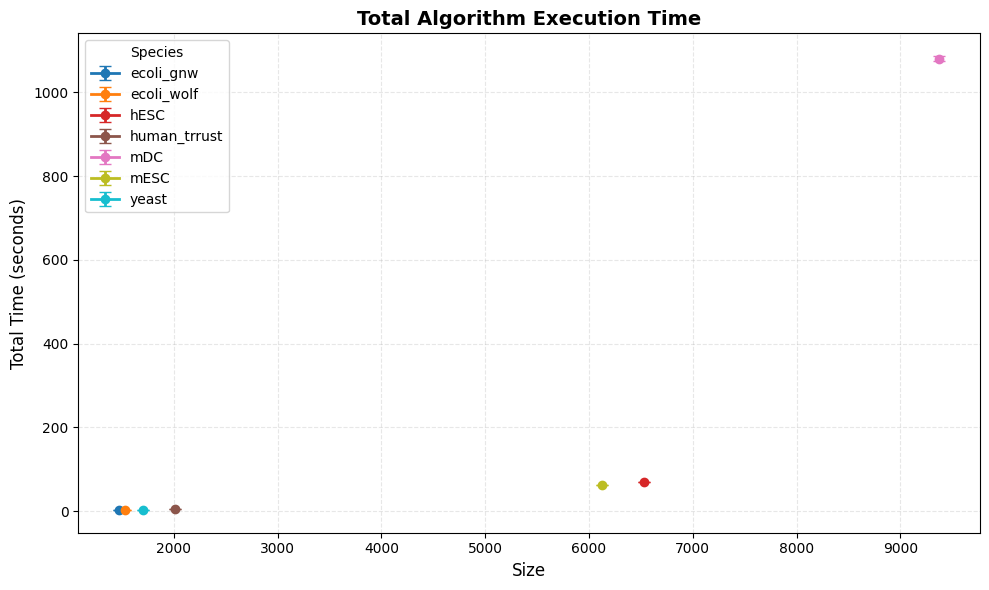

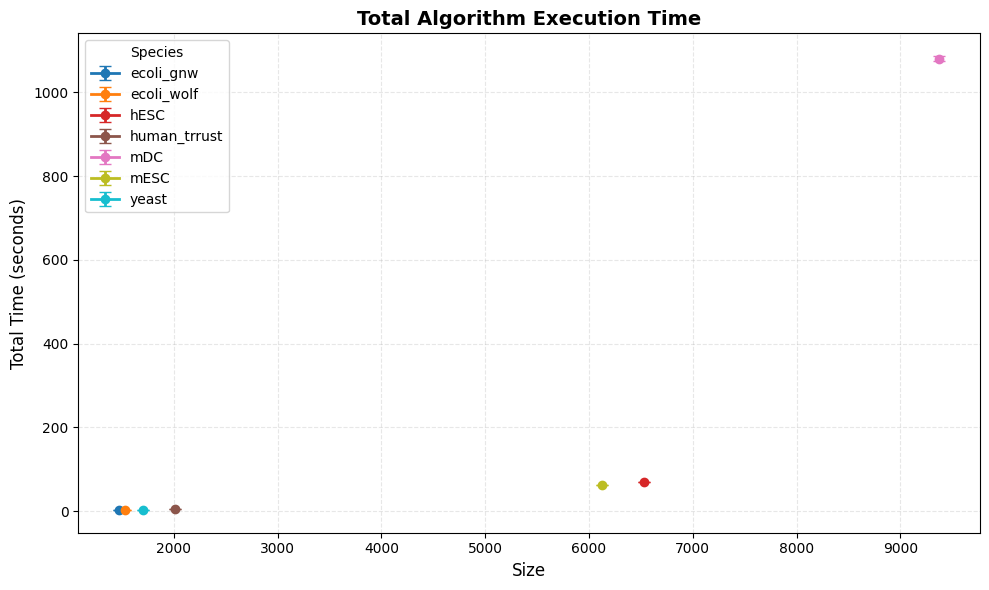

In [2]:
def plot_total_execution_time(
    aggregated_data: pd.DataFrame,
    error_type: str = 'sem',
    figsize: tuple = (10, 6),
    save_path: str = None
) -> plt.Figure:
    """
    Plot total execution time (sum of both phases) with error bars.
    """
    # Calculate total time statistics
    data = aggregated_data.copy()
    data['total_mean'] = data['graph_gen_mean'] + data['prop_comp_mean']
    # Propagate errors (assuming independence)
    data['total_error'] = np.sqrt(
        data[f'graph_gen_{error_type}']**2 + data[f'prop_comp_{error_type}']**2
    )
    
    species = data['specie'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(species)))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for idx, specie in enumerate(species):
        specie_data = data[data['specie'] == specie].sort_values('sizes')
        
        ax.errorbar(
            specie_data['sizes'],
            specie_data['total_mean'],
            yerr=specie_data['total_error'],
            label=specie,
            color=colors[idx],
            marker='o',
            markersize=6,
            capsize=4,
            linewidth=2
        )
    
    ax.set_xlabel('Size', fontsize=12)
    ax.set_ylabel('Total Time (seconds)', fontsize=12)
    ax.set_title('Total Algorithm Execution Time', fontsize=14, fontweight='bold')
    ax.legend(title='Species')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

plot_total_execution_time(aggregated_df)